In [38]:
# Loading

import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm
from pathlib import Path
import warnings
import copy
import csv
import pandas as pd

from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

np.random.seed(42)
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Paths
ROOT = Path("Amazon_products")
TRAIN_CORPUS_PATH = ROOT / "train" / "train_corpus.txt"
TEST_CORPUS_PATH  = ROOT / "test" / "test_corpus.txt"
CLASS_PATH = ROOT / "classes.txt"

EMB_DIR = Path("SilverGeneration/EmbeddingsRemake")
X_ALL_PATH = EMB_DIR / "X_train_test_mpnet.pt" # Train + Test embeddings
LABEL_EMB_PATH = EMB_DIR / "labels_base_mpnet.pt" # test base also

MODEL_SAVE = Path("Models")
MODEL_SAVE.mkdir(exist_ok=True)
MODEL_PATH = MODEL_SAVE / "LinearST.pt"

# Load useful data (like silver gen)
def load_classic(path):
    id2text = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            pid, text = line.strip().split("\t", 1)
            id2text[int(pid)] = text
    return id2text

id2text_train = load_classic(TRAIN_CORPUS_PATH)
id2text_test  = load_classic(TEST_CORPUS_PATH)
train_ids = list(id2text_train.keys())
test_ids  = list(id2text_test.keys())
print(test_ids)
n_train = len(train_ids)
n_test  = len(test_ids)
test_ids  = [n_train + i for i in range(n_test)]
print(test_ids)
print(f"Train IDs: {n_train} | Test IDs: {n_test}")

all_ids = train_ids + test_ids
print(len(set(all_ids)))

# Load X_all + split into X_train & X_test
data = torch.load(X_ALL_PATH, weights_only=False)

# ensure tensor (check)
if isinstance(data, np.ndarray):
    data = torch.from_numpy(data)
elif isinstance(data, list):
    data = torch.stack(data)

X_all = data.float().to(device)

"""X_noisy = X_all + 0.2 * torch.randn_like(X_all)
X_noisy = F.normalize(X_noisy, dim=1)
X_all = X_noisy"""

# Load Class names
classes = {}
with open(CLASS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        cid, cname = line.strip().split("\t")
        classes[int(cid)] = cname

n_classes = len(classes) # 531
print(n_classes)

pid2idx = {pid: i for i, pid in enumerate(all_ids)}

# setup class hierarchy and child and parents map

CLASS_HIER_PATH = ROOT / "class_hierarchy.txt"
parents_map = {i: [] for i in range(n_classes)}
children_map = {i: [] for i in range(n_classes)}

with open(CLASS_HIER_PATH, "r") as f:
    for line in f:
        p, c = map(int, line.strip().split("\t"))
        parents_map[c].append(p)
        children_map[p].append(c)

hier_pairs = []
for child, parents in parents_map.items():
    for p in parents:
        hier_pairs.append((p, child))


parent_idx = torch.tensor([p for p, c in hier_pairs], device=device)
child_idx  = torch.tensor([c for p, c in hier_pairs], device=device)

label_emb = torch.load(LABEL_EMB_PATH).float().to(device)
print("Label embeddings:", label_emb.shape)

ROOT_SET = {0, 3, 10, 23, 40, 169}
def node_depth(node):
    # explicit roots
    if node in ROOT_SET:
        return 0
    if len(parents_map[node]) == 0:
        return 0
    return 1 + max(node_depth(p) for p in parents_map[node])


depths = [node_depth(i) for i in range(n_classes)]

print("Max hierarchy depth:", max(depths))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [39]:
class MultiLabelDataset(Dataset):
    """ PyTorch multi-label dataset with fixed document embeddings and hard labels."""
    def __init__(self, pids, labels_dict, scores_dict, n_classes):
        self.pids = pids
        self.labels_dict = labels_dict
        self.scores_dict = scores_dict
        self.n_classes = n_classes

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]
        emb = X_all[pid2idx[pid]]
        y = torch.zeros(self.n_classes)
        labels = self.labels_dict[pid]
        scores = self.scores_dict[pid]

        for c in labels:
            y[c] = 1.0
        # former version
        # for c, s in zip(labels, scores):
        #    y[c] = float(s)

        return {"pid": pid,"X": emb,"y": y}
    

class UnlabeledEmbeddingDataset(Dataset):
    """For unlabeled data"""
    def __init__(self, pids):
        self.pids = pids

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]
        emb = X_all[pid2idx[pid]]
        return {"X": emb, "pid": pid}

    
class LinearClassifier(nn.Module):
    """Simple linear classifier for multi-label prediction from fixed input embeddings."""
    def __init__(self, dim, n_classes, dropout=0.3):
        super().__init__()
        #self.ln = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(dim, n_classes)

    def forward(self, x):
        #x = self.ln(x)
        x = self.dropout(x)
        return self.fc(x)

In [40]:
import matplotlib.pyplot as plt

def plot_all_metrics(results_dict):
    """
    results_dict format:
    {
      "F1_samples": {"Linear": [...], "GNN": [...]},
      "F1_micro":   {"Linear": [...], "GNN": [...]},
      "F1_macro":   {"Linear": [...], "GNN": [...]},
      "Hierarchy_cond":     {"Linear": [...], "GNN": [...]}
    }
    """

    metric_names = ["F1_samples", "F1_micro", "F1_macro", "Hierarchy_cond"]

    # Count how many metrics actually exist
    active_metrics = [m for m in metric_names if m in results_dict]
    n_plots = len(active_metrics)

    plt.figure(figsize=(6 * n_plots, 5))

    for i, metric in enumerate(active_metrics):
        plt.subplot(1, n_plots, i + 1)

        for model_name, values in results_dict[metric].items():
            plt.plot(values, marker="o", label=model_name)

        plt.title(metric.replace("_", " "))
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()


In [41]:
from sklearn.metrics import f1_score, ndcg_score

def evaluate_full(model, loader, k=3):
    """Evaluate function : f1sample, f1macro & f1micro"""
    model.eval()
    
    all_scores = []
    all_true = []
    preds_bin = []

    with torch.no_grad():
        for batch in loader:
            X = batch["X"].to(device)
            y = batch["y"].cpu().numpy()

            y_bin = (y > 0).astype(int)

            logits = model(X)
            prob = torch.sigmoid(logits).cpu().numpy()

            all_scores.extend(prob)
            all_true.extend(y_bin)
            
            sorted_idx = np.argsort(-prob, axis=1)
            pred_bin = np.zeros_like(prob, dtype=int)
            for i in range(prob.shape[0]):
                top1 = sorted_idx[i, 0]
                top2 = sorted_idx[i, 1]
                pred_bin[i, top1] = 1
                pred_bin[i, top2] = 1

                # Top-3 conditionnal
                if k >= 3:
                    top3 = sorted_idx[i, 2]
                    p2 = prob[i, top2]
                    p3 = prob[i, top3]

                    if p3 >= 0.7 * p2:
                        pred_bin[i, top3] = 1

            preds_bin.extend(pred_bin)

    all_scores = np.array(all_scores)
    all_true = np.array(all_true)
    preds_bin = np.array(preds_bin)

    f1_samples = f1_score(all_true, preds_bin, average="samples")  
    f1_micro = f1_score(all_true, preds_bin, average="micro")     
    f1_macro = f1_score(all_true, preds_bin, average="macro")  

    return f1_samples, f1_micro, f1_macro


In [42]:
def hierarchy_respect_ratio(logits, parents_map):
    """
    Measure how often score(parent) >= score(child)
    """
    probs = torch.sigmoid(logits)
    total = 0
    ok = 0
    for child, parents in parents_map.items():
        for p in parents:
            ok += (probs[:, p] >= probs[:, child]).float().sum().item()
            total += probs.size(0)

    return ok / total

In [43]:
model_linear = LinearClassifier(
    dim=X_all.size(1),
    n_classes=n_classes,
    dropout=0.3
).to(device)
optimizer_lin = torch.optim.AdamW([{"params": model_linear.parameters(),"lr": 5e-4}], weight_decay=1e-3)

In [44]:
# with open("SilverGeneration/SilverCombo/unique_silver_all.json", "r", encoding="utf-8") as f:
with open("SilverGeneration/SilverCombo/pseudo_gold_all.json", "r", encoding="utf-8") as f:
    raw = json.load(f)
silver_labels = {int(pid): data["labels"] for pid, data in raw.items()}
silver_scores = {int(pid): data["scores"] for pid, data in raw.items()}

for pid, data in raw.items():
    labels = data["labels"]
    scores = data["scores"]
    
with open("SilverGeneration/SilverCombo/pseudo_gold_linear.json", "r", encoding="utf-8") as f:
    raw = json.load(f)
silver_labels2 = {int(pid): data["labels"] for pid, data in raw.items()}
silver_scores2 = {int(pid): data["scores"] for pid, data in raw.items()}

for pid, data in raw.items():
    labels2 = data["labels"]
    scores2 = data["scores"]

print(len(silver_labels2))
print(len(silver_labels))

# intersection pids
common_pids = set(silver_labels.keys()) & set(silver_labels2.keys())
print("Nb pids communs:", len(common_pids))

merged = {}

for pid in common_pids:
    label2score = {}

    # dataset 1
    for l, s in zip(silver_labels[pid], silver_scores[pid]):
        label2score[l] = max(label2score.get(l, 0.0), s)

    # dataset 2
    for l, s in zip(silver_labels2[pid], silver_scores2[pid]):
        label2score[l] = max(label2score.get(l, 0.0), s)

    merged[pid] = {
        "labels": list(label2score.keys()),
        "scores": list(label2score.values())
    }

print(merged)

silver_labels_merged = {pid: data["labels"] for pid, data in merged.items()}
silver_scores_merged = {pid: data["scores"] for pid, data in merged.items()}
silver_ids = list(silver_labels_merged.keys())
silver_train, silver_val = train_test_split(silver_ids,test_size=0.15,random_state=42)

print(f"Train: {len(silver_train)} examples")
print(f"Val: {len(silver_val)} examples")


train_dataset = MultiLabelDataset(
    silver_train,
    silver_labels_merged,
    silver_scores_merged,
    n_classes
)

val_dataset = MultiLabelDataset(
    silver_val,
    silver_labels_merged,
    silver_scores_merged,
    n_classes
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)

print(len(train_dataset))
print(len(val_dataset))

labeled_ids = set(merged.keys())
all_ids_set = set(all_ids)
unlabeled_ids = list(all_ids_set - labeled_ids)

print("Nb total docs:", len(all_ids))
print("Nb labeled (silver + pseudo-gold):", len(labeled_ids))
print("Nb unlabeled:", len(unlabeled_ids))

unlabeled_dataset = UnlabeledEmbeddingDataset(unlabeled_ids)
unlabeled_loader = DataLoader(unlabeled_dataset,batch_size=128,shuffle=False)

current_labels = silver_labels_merged
current_scores = silver_scores_merged
print(len(current_labels))

37941
13479
Nb pids communs: 11986
{0: {'labels': [118, 74, 23], 'scores': [1.0, 0.7, 0.5]}, 3: {'labels': [93, 64, 10], 'scores': [1.0, 1.0, 0.5]}, 5: {'labels': [43, 24, 23], 'scores': [1.0, 1.0, 0.5]}, 6: {'labels': [21, 3, 108, 301], 'scores': [1.0, 0.7, 1.0, 1.0]}, 7: {'labels': [32, 31, 23], 'scores': [1.0, 0.7, 0.5]}, 32774: {'labels': [212, 211, 0, 216], 'scores': [1.0, 1.0, 0.5, 1.0]}, 32775: {'labels': [6, 5, 3], 'scores': [1.0, 1.0, 0.5]}, 12: {'labels': [197, 60, 10, 47], 'scores': [1.0, 0.7, 0.5, 1.0]}, 13: {'labels': [43, 24, 23], 'scores': [1.0, 1.0, 0.5]}, 14: {'labels': [42, 41, 40, 385], 'scores': [1.0, 1.0, 0.5, 1.0]}, 32783: {'labels': [42, 41, 40, 102], 'scores': [1.0, 1.0, 0.5, 1.0]}, 32784: {'labels': [220, 10, 221, 242], 'scores': [1.0, 0.7, 1.0, 1.0]}, 32785: {'labels': [70, 4, 3, 375], 'scores': [1.0, 1.0, 0.5, 1.0]}, 32786: {'labels': [21, 3, 187, 68], 'scores': [1.0, 0.7, 1.0, 1.0]}, 32789: {'labels': [510, 220, 10, 496], 'scores': [1.0, 0.7, 0.5, 1.0]}, 24:

In [45]:
C = n_classes
all_classes = set(range(C))

parents_closure = {
    c: set(parents_map[c]) for c in range(C)
}
children_closure = {
    c: set(children_map[c]) for c in range(C)
}


def build_mask_for_one_doc(core_classes, C, parents_closure, children_closure):
    """
    Build pos/neg mask rows for a single document.
    """
    if len(core_classes) == 0:
        return torch.zeros(C), torch.zeros(C)

    positive = set(core_classes)
    children_union = set()

    for c in core_classes:
        positive.update(parents_closure[c])
        children_union.update(children_closure[c])

    negative = all_classes - positive - children_union

    pos_row = torch.zeros(C)
    neg_row = torch.zeros(C)

    pos_row[list(positive)] = 1.0
    neg_row[list(negative)] = 1.0

    return pos_row, neg_row

current_ids = list(current_labels.keys())
pid2cur_idx = {pid: i for i, pid in enumerate(current_ids)}

pos_rows = []
neg_rows = []

for pid in current_ids:
    pos_row, neg_row = build_mask_for_one_doc(
        current_labels[pid],
        C,
        parents_closure,
        children_closure
    )
    pos_rows.append(pos_row)
    neg_rows.append(neg_row)

pos_mask = torch.stack(pos_rows)
neg_mask = torch.stack(neg_rows)

print("Initial masks built:", pos_mask.shape)

def core_loss(p, pos_mask, neg_mask):
    """
    Hierarchical core loss (TaxoClass-style)
    p: [B, C] probabilities
    pos_mask, neg_mask: [B, C]
    """
    eps = 1e-8
    loss_pos = -(pos_mask * torch.log(p + eps)).sum()
    loss_neg = -(neg_mask * torch.log(1 - p + eps)).sum()
    return loss_pos + loss_neg

def compute_class_thresholds(
    probs_all, current_labels, n_classes, base_threshold=0.85, percentile=90
):
    class_thresholds = {}

    for c in range(n_classes):
        class_probs = [
            probs_all[pid2idx[pid], c]
            for pid, labels in current_labels.items()
            if c in labels and pid2idx[pid] < probs_all.shape[0]
        ]

        if len(class_probs) < 30:
            class_thresholds[c] = base_threshold - 0.05
            continue

        threshold = np.percentile(class_probs, percentile)

        freq = len(class_probs)
        freq_penalty = min(0.15, np.log(freq + 1) / 10)

        threshold = min(0.975, max(base_threshold, threshold + freq_penalty))
        class_thresholds[c] = threshold

    return class_thresholds



Initial masks built: torch.Size([11986, 531])


In [46]:
model_linear_student = LinearClassifier(
    dim=X_all.size(1),
    n_classes=n_classes,
    dropout=0.3
).to(device)
optimizer_lin = torch.optim.AdamW([{"params": model_linear_student.parameters(),"lr": 5e-4}], weight_decay=1e-3)

model_linear_teacher = LinearClassifier(
    dim=X_all.size(1),
    n_classes=n_classes,
    dropout=0.0
).to(device)
model_linear_teacher.load_state_dict(model_linear_student.state_dict())

current_ids = list(current_labels.keys())
pid2cur_idx = {pid: i for i, pid in enumerate(current_ids)}

current_ids = list(current_labels.keys())
pid2cur_idx = {pid: i for i, pid in enumerate(current_ids)}
silver_labels_original = copy.deepcopy(silver_labels_merged)
silver_scores_original = copy.deepcopy(silver_scores_merged)
pseudo_labels = {}
pseudo_scores = {}

In [ ]:
def train_one_model(student, teacher, MODEL_PATH, optimizer, use_cons):
    """Train Model Self training"""
    global current_ids, pos_mask, neg_mask, pseudo_labels, pseudo_scores, current_labels, current_scores

    optimizer = optimizer
    pid2cur_idx = {pid: i for i, pid in enumerate(current_ids)}

    # hyperparameters
    epochs = 100
    val_f1s_list = []
    val_f1m_list = []
    val_f1mic_list = []
    val_hier_list = []

    best_f1 = 0
    best_state = None
    patience = 20
    wait = 0

    ema_alpha = 0.975
    lambda_cons = 2.0

    # for pseudo labeling
    pseudo_warmup = 5
    pseudo_add_freq = 4
    pseudo_check_freq = 2

    min_pseudo_conf_add = 0.80
    min_pseudo_conf_remove = 0.80
    class_confidence_history = {c: [] for c in range(n_classes)}

    max_pseudo_per_step = 1000
    num_top_classes = 3
    pseudo_added = set()
    unlabeled = set(unlabeled_ids)

    for epoch in range(1, epochs + 1):

        # Ralentir + threshold plus strict
        if epoch < 40:
            max_pseudo_per_step = 750
            min_pseudo_conf_add  = 0.85
            min_pseudo_conf_remove = 0.80
        elif epoch < 80:
            max_pseudo_per_step = 500
            min_pseudo_conf_add  = 0.90
            min_pseudo_conf_remove = 0.84
        else:
            max_pseudo_per_step = 250
            min_pseudo_conf_add  = 0.95
            min_pseudo_conf_remove = 0.89


        labeled_ids = list(current_labels.keys())
        train_dataset = MultiLabelDataset(labeled_ids, current_labels, current_scores, n_classes)
        train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

        unl_dataset = UnlabeledEmbeddingDataset(list(unlabeled))
        unl_loader = DataLoader(unl_dataset, batch_size=128, shuffle=True)
        unl_iter = iter(unl_loader)

        student.train()
        total_loss_sum = 0.0 
        total_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
            X = batch["X"].to(device)
            y = batch["y"].to(device)
            pids = batch["pid"]

            # mask for regularization
            logits = student(X)
            p = torch.sigmoid(logits)
            
            idx = torch.tensor(
                [pid2cur_idx[pid.item()] for pid in pids],
            )
            pos_mask_b = pos_mask[idx].to(device)   # [B, C]
            neg_mask_b = neg_mask[idx].to(device)   # [B, C]

            supervised_loss = core_loss(p, pos_mask_b, neg_mask_b)

            # consistency loss on unlabeled
            consistency_loss = 0.0
            if use_cons and unl_loader is not None and len(unlabeled) > 0:
                try:
                    unl_batch = next(unl_iter)
                except StopIteration:
                    unl_iter = iter(unl_loader)
                    unl_batch = next(unl_iter)
                
                X_unl = unl_batch["X"].to(device)
                with torch.no_grad():
                    logits_teacher = teacher(X_unl) # with teacher
    
                # noise predictions
                noise = torch.randn_like(X_unl) * 0.1  # Gaussian noise
                X_unl_noisy = X_unl + noise
                logits_student = student(X_unl_noisy)
    
                # Consistency loss
                consistency_loss = F.mse_loss(
                    torch.sigmoid(logits_student), 
                    torch.sigmoid(logits_teacher)
                )

            total_loss = supervised_loss + lambda_cons * consistency_loss
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            total_loss_sum += total_loss.item()

        avg_loss = total_loss_sum / len(train_loader)

        # ema update
        with torch.no_grad():
            for t, s in zip(teacher.parameters(), student.parameters()):
                t.data = ema_alpha * t.data + (1 - ema_alpha) * s.data

        teacher.eval()
        f1s, f1mic, f1mac = evaluate_full(teacher, val_loader)

        with torch.no_grad():
            batch = next(iter(val_loader))
            X = batch["X"].to(device)
            logits = teacher(X)
            ratio = hierarchy_respect_ratio(logits, parents_map)
            print(f"HIERARCHY RESPECT RATIO = {ratio:.4f}")

        val_f1mic_list.append(f1mic)
        val_f1m_list.append(f1mac)
        val_hier_list.append(ratio)
        val_f1s_list.append(f1s)


        print(f"[Epoch {epoch}] loss={avg_loss:.4f} | F1mic={f1mic:.4f} | F1s={f1s:.4f} | F1mac={f1mac:.4f}")

        # Early stopping + best model choice based on f1micro
        if f1mic > best_f1:
            best_f1 = f1mic
            best_state = copy.deepcopy(teacher.state_dict())
            torch.save(best_state, MODEL_PATH)
            print(f"New best model (F1={best_f1:.4f})")
            wait = 0
        else:
            wait += 1
            print(f" No improvement for {wait} epoch(s).")

        if wait >= patience:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

        
        if epoch >= pseudo_warmup and epoch % pseudo_add_freq == 0 and len(unlabeled) > 0:
            teacher.eval()
            with torch.no_grad():
                u_list = list(unlabeled)
                idxs = torch.tensor([pid2idx[p] for p in u_list], device=device)
                probs_all = torch.sigmoid(teacher(X_all.to(device))).cpu().numpy()
                probs_unl = probs_all[idxs.cpu().numpy()]

            class_thresholds = compute_class_thresholds(
                probs_all, current_labels, n_classes, min_pseudo_conf_add
            )            
            conf = probs_unl.max(axis=1)
            order = np.argsort(-conf)

            added = 0
            for k in order:
                if added >= max_pseudo_per_step:
                    break

                pid = u_list[k]
                pred = probs_unl[k]
                """best = pred.argsort()[-num_top_classes:][::-1]

                labels, scores = [], []
                for cls in best:
                    score = pred[cls]
                    if score < class_thresholds[cls]:
                        continue
                    labels.append(int(cls))
                    scores.append(float(score))"""
                
                cls = int(pred.argmax())
                score = float(pred[cls])

                if score < class_thresholds[cls]:
                    continue

                labels = [cls]
                scores = [score]

                if len(labels) == 0:
                    continue

                all_parents = set()
                for lbl in labels:
                    all_parents.update(parents_closure[lbl])
                
                if len(all_parents) > 0:
                    best_parent = max(all_parents, key=lambda p: pred[p])
                    best_parent_score = pred[best_parent]
                    if best_parent not in labels:
                        labels.append(int(best_parent))
                        scores.append(float(best_parent_score))

                # add
                current_labels[pid] = labels
                pseudo_labels[pid] = labels
                pseudo_scores[pid] = scores
                current_scores[pid] = scores
                pseudo_added.add(pid)
                unlabeled.remove(pid)

                # append masks
                pos_row, neg_row = build_mask_for_one_doc(labels,C,parents_closure,children_closure)

                device_mask = pos_mask.device
                pos_mask = torch.cat([pos_mask, pos_row.unsqueeze(0).to(device_mask)], dim=0)
                neg_mask = torch.cat([neg_mask, neg_row.unsqueeze(0).to(device_mask)], dim=0)

                pid2cur_idx[pid] = len(pos_mask) - 1
                current_ids.append(pid)

                added += 1

            print(f"[ST] Added {added} pseudo-labels | Unlabeled left: {len(unlabeled)}")

        if epoch >= pseudo_warmup and epoch % pseudo_check_freq == 0 and len(pseudo_added) > 0:
            teacher.eval()
            with torch.no_grad():
                probs_all = torch.sigmoid(teacher(X_all.to(device))).cpu().numpy()

            to_remove = []
            for pid in list(pseudo_added):
                if probs_all[pid2idx[pid]].max() < min_pseudo_conf_remove:
                    to_remove.append(pid)

            if len(to_remove) > 0:
                for pid in to_remove:
                    pseudo_labels.pop(pid)
                    pseudo_scores.pop(pid)
                    current_labels.pop(pid)
                    current_scores.pop(pid)
                    pseudo_added.remove(pid)
                    unlabeled.add(pid)

                # rebuild masks ONLY for removed docs
                current_ids = list(current_labels.keys())
                pid2cur_idx = {pid: i for i, pid in enumerate(current_ids)}

                pos_rows, neg_rows = [], []
                for pid in current_ids:
                    pos_row, neg_row = build_mask_for_one_doc(current_labels[pid],C,parents_closure,children_closure)
                    pos_rows.append(pos_row)
                    neg_rows.append(neg_row)

                pos_mask = torch.stack(pos_rows).to(device)
                neg_mask = torch.stack(neg_rows).to(device)

            print(f"[ST] Removed {len(to_remove)} pseudo-labels")

    print(f"Best validation F1 = {best_f1:.4f}")
    print(f"Silver labels: {len(silver_labels_original)}")
    print(f"Pseudo labels: {len(pseudo_labels)}")
    print(f"Total: {len(current_labels)}")

    teacher.load_state_dict(best_state)
    save_model = copy.deepcopy(teacher)
    print(torch.sigmoid(logits[0])[:10])

    return val_f1s_list, val_f1mic_list, val_f1m_list, val_hier_list, save_model

# =====================================

MODEL_PATH_LINEAR = "Models/best_linear.pt"
#gnn_results = train_one_model(model_gnn, MODEL_PATH_GNN, use_hier = True)
linear_results = train_one_model(model_linear_student, model_linear_teacher, MODEL_PATH_LINEAR, optimizer_lin, use_cons = False)

Epoch 1/100: 100%|██████████| 94/94 [00:00<00:00, 116.95it/s]


HIERARCHY RESPECT RATIO = 0.4867
[Epoch 1] loss=38902.7590 | F1mic=0.0128 | F1s=0.0127 | F1mac=0.0013
New best model (F1=0.0128)


Epoch 2/100: 100%|██████████| 94/94 [00:00<00:00, 145.39it/s]


HIERARCHY RESPECT RATIO = 0.4952
[Epoch 2] loss=28681.0033 | F1mic=0.0271 | F1s=0.0269 | F1mac=0.0025
New best model (F1=0.0271)


Epoch 3/100: 100%|██████████| 94/94 [00:00<00:00, 145.05it/s]


...

HIERARCHY RESPECT RATIO = 0.8608
[Epoch 98] loss=442.2733 | F1mic=0.7107 | F1s=0.7172 | F1mac=0.1476
New best model (F1=0.7107)
[ST] Removed 0 pseudo-labels


Epoch 99/100: 100%|██████████| 113/113 [00:00<00:00, 219.94it/s]


HIERARCHY RESPECT RATIO = 0.8614
[Epoch 99] loss=434.3261 | F1mic=0.7118 | F1s=0.7183 | F1mac=0.1495
New best model (F1=0.7118)


Epoch 100/100: 100%|██████████| 113/113 [00:00<00:00, 219.81it/s]


HIERARCHY RESPECT RATIO = 0.8618
[Epoch 100] loss=432.7587 | F1mic=0.7117 | F1s=0.7183 | F1mac=0.1503
 No improvement for 1 epoch(s).
[ST] Added 250 pseudo-labels | Unlabeled left: 34475
[ST] Removed 0 pseudo-labels
Best validation F1 = 0.7118
Silver labels: 11986
Pseudo labels: 2684
Total: 14670
tensor([0.0061, 0.0055, 0.0052, 0.0078, 0.0054, 0.0032, 0.0030, 0.0062, 0.0081,
        0.0013], device='cuda:0')


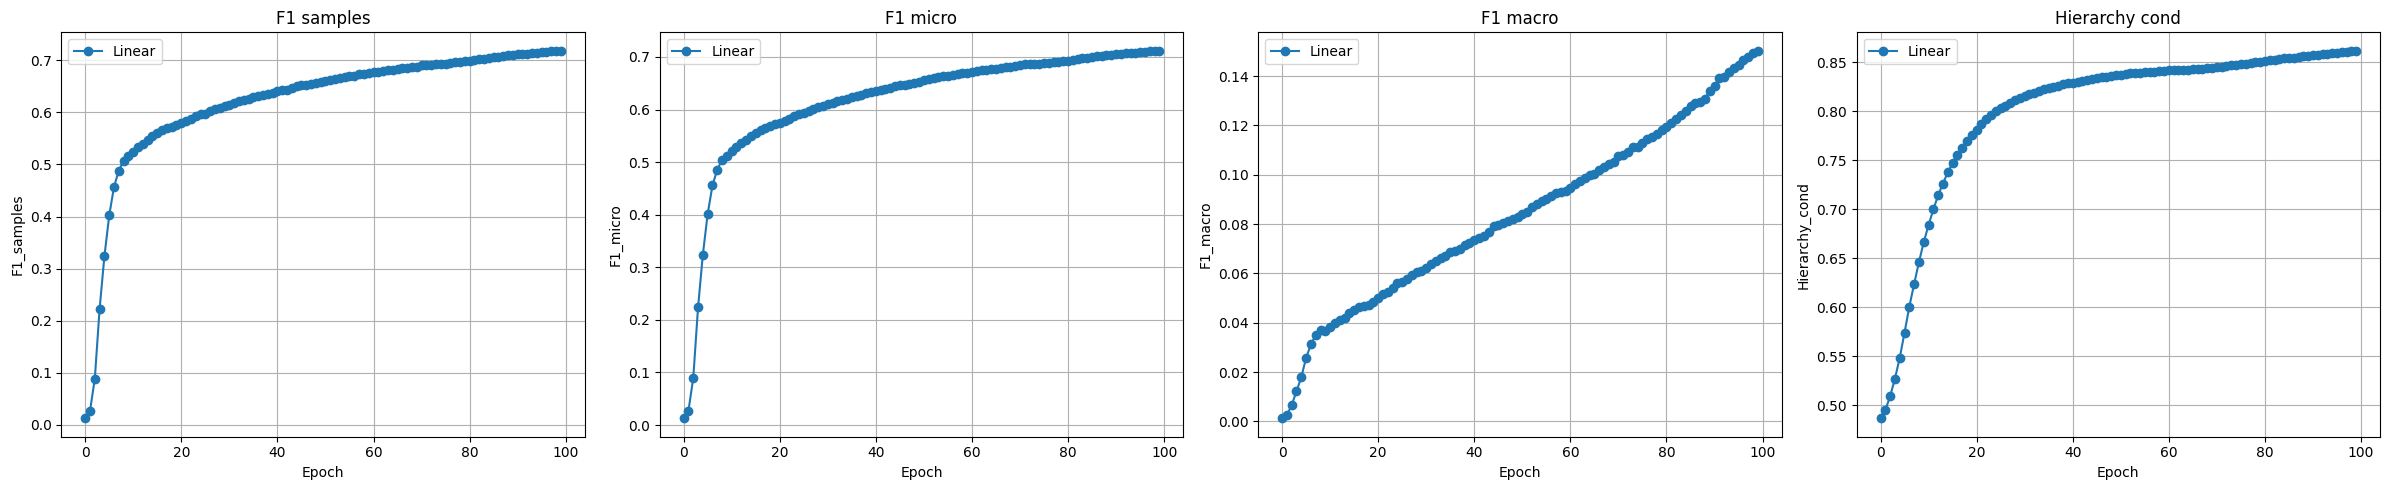

In [48]:
val_f1s_linear, val_f1mic_linear, val_f1m_linear, val_hier_linear, save_model_linear = linear_results

results_dict = {
    "F1_samples":{"Linear": val_f1s_linear},
    "F1_micro": {"Linear": val_f1mic_linear},
    "F1_macro": {"Linear": val_f1m_linear},
    "Hierarchy_cond": {"Linear": val_hier_linear},
}

plot_all_metrics(results_dict)

Top-20 leaf classes: [3, 220, 93, 0, 64, 49, 131, 17, 206, 199, 4, 40, 271, 32, 43, 129, 44, 118, 170, 89]


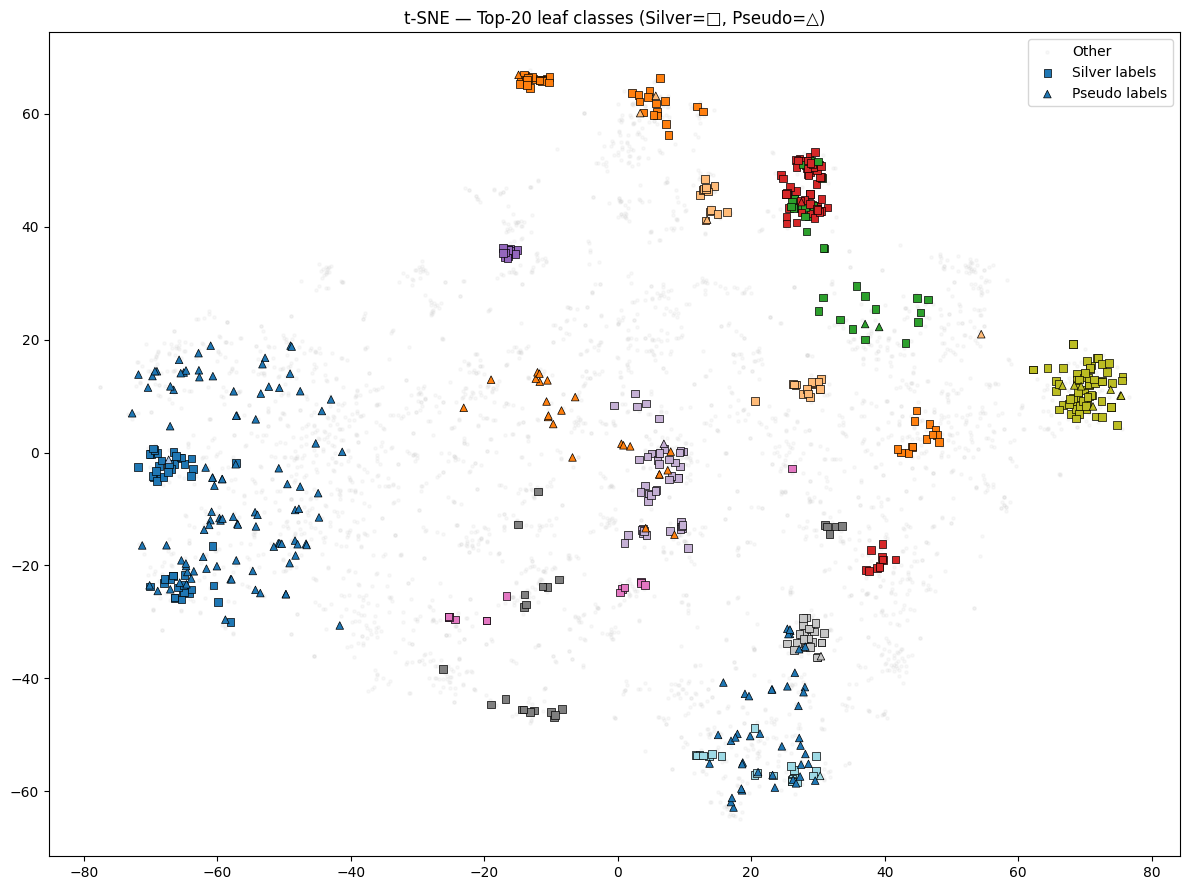

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from collections import Counter

def tsne_visualize(X_all, all_ids, current_labels, silver_labels_original, pseudo_labels, TOP_K=20, N=4000):
    """Visualize embeddings in 2D via t-SNE with squares for silver labels and triangles for pseudo-labels."""

    X = X_all.cpu().numpy()
    idx = np.random.choice(len(X), min(N, len(X)), replace=False)

    X_sub = X[idx]
    ids_sub = np.array(all_ids)[idx]

    leaf_labels = np.array([
        current_labels[pid][0] if pid in current_labels else -1
        for pid in ids_sub
    ])

    # Identifier silver vs pseudo
    is_silver = np.array([
        pid in silver_labels_original for pid in ids_sub
    ])
    is_pseudo = np.array([
        pid in pseudo_labels for pid in ids_sub
    ])

    cnt = Counter(leaf_labels[leaf_labels >= 0])
    top_leafs = {lab for lab, _ in cnt.most_common(TOP_K)}

    top_class_ids = [lab for lab, _ in cnt.most_common(TOP_K)]
    print(f"Top-{TOP_K} leaf classes:", top_class_ids)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_emb = tsne.fit_transform(X_sub)
    
    plt.figure(figsize=(12, 9))
    mask_top = np.isin(leaf_labels, list(top_leafs))

    # Other classes (gris)
    mask_other = ~mask_top
    plt.scatter(
        X_emb[mask_other, 0],
        X_emb[mask_other, 1],
        s=5, alpha=0.15, color="lightgray", label="Other", marker='o'
    )

    # Top classes - Silver labels (carrés)
    mask_silver_top = mask_top & is_silver
    if mask_silver_top.any():
        plt.scatter(
            X_emb[mask_silver_top, 0],
            X_emb[mask_silver_top, 1],
            s=30,
            c=leaf_labels[mask_silver_top],
            cmap="tab20",
            label="Silver labels",
            marker='s',
            edgecolors='black',
            linewidths=0.5
        )

    # Top classes - Pseudo labels (triangles)
    mask_pseudo_top = mask_top & is_pseudo
    if mask_pseudo_top.any():
        plt.scatter(
            X_emb[mask_pseudo_top, 0],
            X_emb[mask_pseudo_top, 1],
            s=30,
            c=leaf_labels[mask_pseudo_top],
            cmap="tab20",
            label="Pseudo labels",
            marker='^',
            edgecolors='black',
            linewidths=0.5
        )

    plt.title(f"t-SNE — Top-{TOP_K} leaf classes (Silver=□, Pseudo=△)")
    plt.legend()
    plt.tight_layout()
    plt.show()


tsne_visualize(X_all, all_ids, current_labels, silver_labels_original, pseudo_labels)

In [50]:
def select_k(prob, min_k=2, max_k=3):
    """
    Select the top-k labels based on probability with a confidence-based
    """
    idx = np.argsort(prob)[::-1]
    top3 = idx[:max_k]
    if prob[top3[2]] < 0.70 * prob[top3[1]]:
        return top3[:2]
    return top3

def run_submission(model, test_ids, X_all, pid2idx, n_train, out_path):
    """
    Run inference on the test set and generate a submission file with
    predicted labels for each sample.
    """
    model.eval()
    preds = []
    batch_size = 64
    with torch.no_grad():
        for b_start in tqdm(range(0, len(test_ids), batch_size)):
            batch_pids = test_ids[b_start:b_start + batch_size]

            batch_emb = torch.stack([X_all[pid2idx[pid]] for pid in batch_pids]).to(device)

            logits = model(batch_emb)
            probs = torch.sigmoid(logits).cpu().numpy()

            for p in probs:
                labels = select_k(p)
                preds.append([str(x) for x in labels])

    OUT_DIR = Path("Submission")
    OUT_DIR.mkdir(exist_ok=True)

    with open(out_path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["id", "label"])
        for pid, labels in zip(test_ids, preds):
            true_test_id = pid - n_train
            w.writerow([true_test_id, ",".join(labels)])

    print(f"Submission saved -> {out_path}")

run_submission(
    model=save_model_linear,
    test_ids=test_ids,
    X_all=X_all,
    pid2idx=pid2idx,
    n_train=n_train,
    out_path="Submission/submission_linear_st.csv"
)

100%|██████████| 308/308 [00:00<00:00, 439.76it/s]

Submission saved -> Submission/submission_linear_st.csv
